<a href="https://www.kaggle.com/code/kckdfh2ks3udfhgg9/car-price-prediction-random-forest-swe?scriptVersionId=345464817" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**to import data**

In [1]:
import os 
for d, _, files in os.walk('/kaggle/input'):
    for name in files :
        print(d + '/' + name)

/kaggle/input/car-price-01/Car Price.csv


**to import pandas and analysis data **

In [2]:
import pandas as pd
#df is Variable
df= pd.read_csv('/kaggle/input/car-price-01/Car Price.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**to Chek how much Row & Coumn **

In [3]:
df.shape

(205, 26)

**to see the tayp of data any Coulmn**

In [4]:
#this is important to know what Encoding requires 
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

**we identify the columns with missing Values to see what we will do **

In [5]:
#.isna see null V 
#.mean see average
df.isna().mean().sort_values(ascending=False).head(26)


car_ID              0.0
symboling           0.0
highwaympg          0.0
citympg             0.0
peakrpm             0.0
horsepower          0.0
compressionratio    0.0
stroke              0.0
boreratio           0.0
fuelsystem          0.0
enginesize          0.0
cylindernumber      0.0
enginetype          0.0
curbweight          0.0
carheight           0.0
carwidth            0.0
carlength           0.0
wheelbase           0.0
enginelocation      0.0
drivewheel          0.0
carbody             0.0
doornumber          0.0
aspiration          0.0
fueltype            0.0
CarName             0.0
price               0.0
dtype: float64

In [6]:
#stor messing ratios in variable 
null_ratios=df.isna().mean()
null_ratios

car_ID              0.0
symboling           0.0
CarName             0.0
fueltype            0.0
aspiration          0.0
doornumber          0.0
carbody             0.0
drivewheel          0.0
enginelocation      0.0
wheelbase           0.0
carlength           0.0
carwidth            0.0
carheight           0.0
curbweight          0.0
enginetype          0.0
cylindernumber      0.0
enginesize          0.0
fuelsystem          0.0
boreratio           0.0
stroke              0.0
compressionratio    0.0
horsepower          0.0
peakrpm             0.0
citympg             0.0
highwaympg          0.0
price               0.0
dtype: float64

In [7]:
target='price'
#to see if price C or not
df[target].head()

0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

** now import matplotlib **

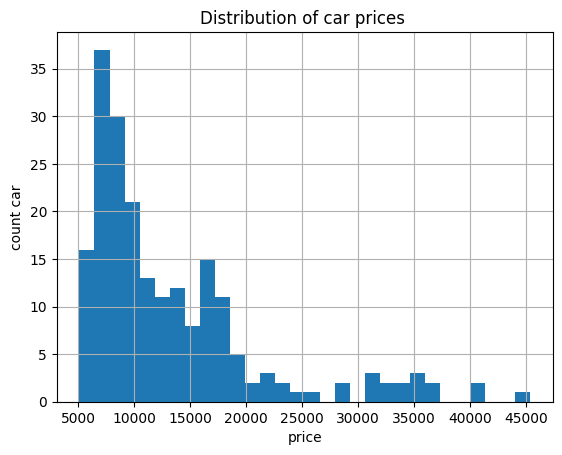

In [8]:
import matplotlib.pyplot as plt
df[target].hist(bins=30)
plt.title("Distribution of car prices ")
plt.xlabel('price')
plt.ylabel('count car')
plt.show()

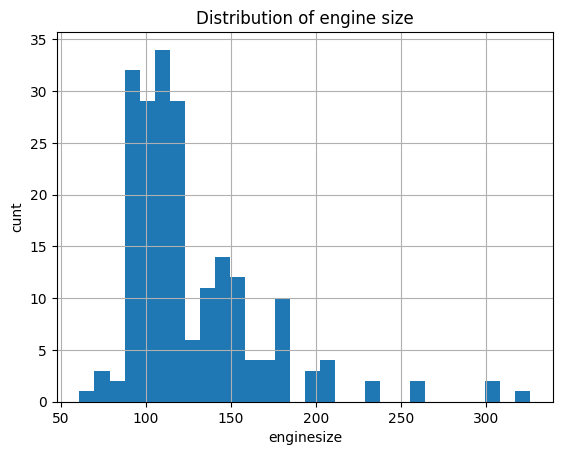

In [9]:
df['enginesize'].hist(bins=30)
plt.title("Distribution of engine size")
plt.xlabel('enginesize')
plt.ylabel('cunt')
plt.show()
#Most engines are between 80 and 160 

** for horse power **

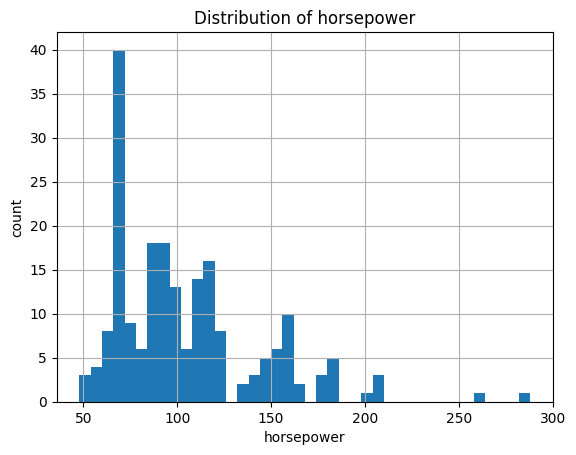

In [10]:
df['horsepower'].hist(bins=40)
plt.title('Distribution of horsepower')
plt.xlabel('horsepower')
plt.ylabel('count')
plt.show()

**The relationship between engine size and price**

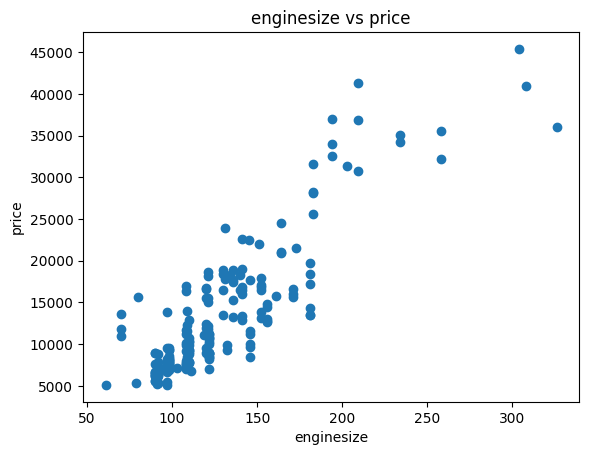

In [11]:
plt.scatter(df['enginesize'],df[target])
plt.title('enginesize vs price')
plt.xlabel('enginesize')
plt.ylabel('price')
plt.show()

**The relationship between horsepower and price**

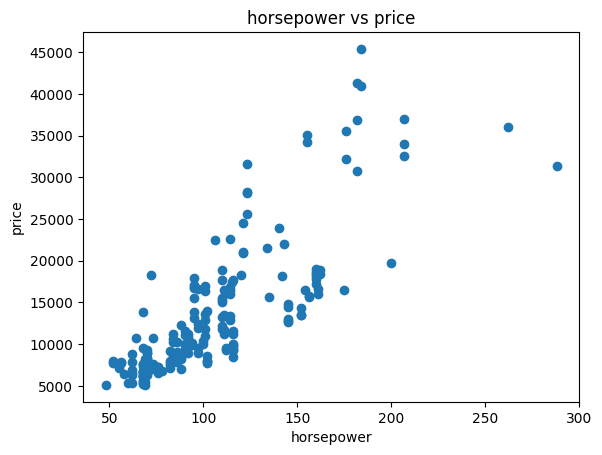

In [12]:
plt.scatter(df['horsepower'], df[target])
plt.title('horsepower vs price')
plt.xlabel('horsepower')
plt.ylabel('price')
plt.show()

**The relationship between Curbweight and price**

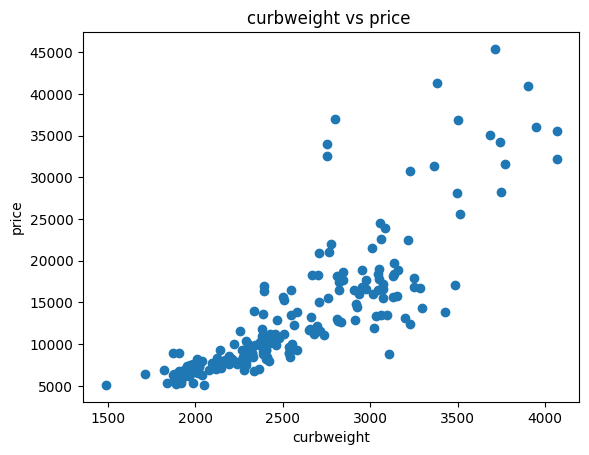

In [13]:
plt.scatter(df['curbweight'],df[target])
plt.title('curbweight vs price ')
plt.xlabel('curbweight')
plt.ylabel('price')
plt.show()

**We now see all the relationships between the columns**

In [14]:
num_cols = df.select_dtypes(include=[float,int]).columns
num_cols

corr=df[num_cols].corr()
corr

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


**Drwing Heatmap**

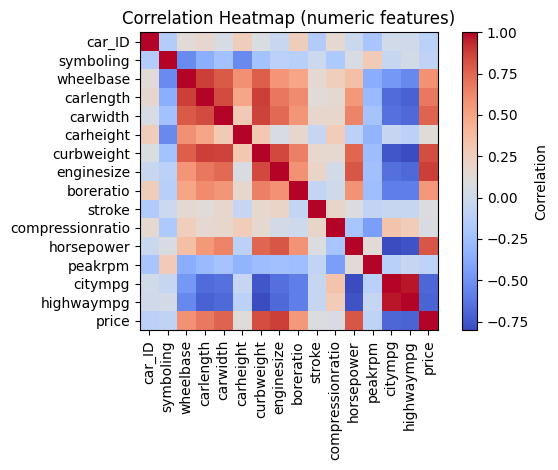

In [15]:
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

**Numbers**

In [16]:
corr_with_price = corr['price'].sort_values(ascending=False)
corr_with_price

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
car_ID             -0.109093
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

**We begin with a detailed enumeration of three features.**

In [17]:
cols_for_stats = ['price', 'enginesize', 'horsepower']
df[cols_for_stats].describe()

,price,enginesize,horsepower
count,205.000000,205.000000,205.000000
mean,13276.710571,126.907317,104.117073
std,7988.852332,41.642693,39.544167
min,5118.000000,61.000000,48.000000
25%,7788.000000,97.000000,70.000000
50%,10295.000000,120.000000,95.000000
75%,16503.000000,141.000000,116.000000
max,45400.000000,326.000000,288.000000


**We calculate Q1, Q3, IQR, Upper, Lower for the price**

In [18]:
col = 'price'

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(' q1 =',q1,' q3 =', q3,' iqr =', iqr,' lower =', lower,' upper =', upper)

 q1 = 7788.0  q3 = 16503.0  iqr = 8715.0  lower = -5284.5  upper = 29575.5


**We calculate Q1, Q3, IQR, Upper, Lower for the enginesize**

In [19]:
col = 'enginesize'

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(' q1 =',q1,' q3 =', q3,' iqr =', iqr,' lower =', lower,' upper =', upper)

 q1 = 97.0  q3 = 141.0  iqr = 44.0  lower = 31.0  upper = 207.0


**We calculate Q1, Q3, IQR, Upper, Lower for the horsepower**

In [20]:
col = 'horsepower'

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(' q1 =',q1,' q3 =', q3,' iqr =', iqr,' lower =', lower,' upper =', upper)

 q1 = 70.0  q3 = 116.0  iqr = 46.0  lower = 1.0  upper = 185.0


**We only select classes whose prices are within normal limits.**

In [21]:
col = 'price'

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean = df[(df[col] >= lower) & (df[col] <= upper)]
df_clean.shape

(190, 26)

**We are now working on clean data.**

In [22]:
data = df_clean   

y = data['price']
X = data.drop(columns=['price'])

X.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22


In [23]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features

['car_ID',
 'symboling',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginesize',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg']

In [24]:
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
categorical_features

['CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'enginetype',
 'cylindernumber',
 'fuelsystem']

**Data segmentation: Train / Test**

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% Train  and 20% Test
    random_state=42     # A fixed number so that the division is repeated in the same way
)
X_train.shape, X_test.shape


((152, 25), (38, 25))

** import wgat we need for modling**

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math

**We are building Transformer for digital columns**

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [28]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

**We combine the two in ColumnTransformer**

In [29]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['car_ID', 'symboling', 'wheelbase',
                                  'carlength', 'carwidth', 'carheight',
                                  'curbweight', 'enginesize', 'boreratio',
                                  'stroke', 'compressionratio', 'horsepower',
                                  'peakrpm', 'citympg', 'highwaympg']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['CarName', 'fueltype', 'aspiration',
                                  'doornumber', 'carbody', 'drivewheel',
                                  'enginelocation', 'enginetype',
                                  'cylindernumber', 'fuelsystem'])])

**Model definition + Pipeline**

In [30]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

model_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['car_ID', 'symboling',
                                                   'wheelbase', 'carlength',
                                                   'carwidth', 'carheight',
                                                   'curbweight', 'enginesize',
                                                   'boreratio', 'stroke',
                                                   'compressionratio',
                                                   'horsepower', 'peakrpm',
                                                   'citympg', 'highwaympg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CarName', 'fueltype',
                                                   'aspiration', 'doornumber',
                                                   'carbody', 'drivewheel',
                                                   'enginelocation',
                                                   'enginetype',
                                                   'cylindernumber',
                                                   'fuelsystem'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

**We train the model (fit)**

In [31]:
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['car_ID', 'symboling',
                                                   'wheelbase', 'carlength',
                                                   'carwidth', 'carheight',
                                                   'curbweight', 'enginesize',
                                                   'boreratio', 'stroke',
                                                   'compressionratio',
                                                   'horsepower', 'peakrpm',
                                                   'citympg', 'highwaympg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CarName', 'fueltype',
                                                   'aspiration', 'doornumber',
                                                   'carbody', 'drivewheel',
                                                   'enginelocation',
                                                   'enginetype',
                                                   'cylindernumber',
                                                   'fuelsystem'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

**We measure the model's performance on the Training set**

In [32]:
train_preds = model_pipe.predict(X_train)

from sklearn.metrics import mean_squared_error, r2_score
import math

train_rmse = math.sqrt(mean_squared_error(y_train, train_preds))
train_r2 = r2_score(y_train, train_preds)

train_rmse, train_r2

(736.3307623573334, 0.978686138186518)

**we will test modl**

In [33]:
test_preds = model_pipe.predict(X_test)

test_rmse = math.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

test_rmse, test_r2

(1106.9359863090203, 0.9271064168466002)

In [34]:
results_df = pd.DataFrame(
    {
        "RMSE": [train_rmse, test_rmse],
        "R²":   [train_r2,   test_r2]
    },
    index=["Train", "Test"]
)

results_df.style.format({
    "RMSE": "{:,.2f}",  
    "R²":   "{:.3f}" 
})

,RMSE,R²
Train,736.33,0.979
Test,"1,106.94",0.927
